In [1]:
!pip install requests


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import requests
from nemosis import dynamic_data_compiler

In [ ]:
# Import and clean necessary energy data using NEMOSIS API for AEMO data retrieval
# Define the timeframe (Summer 2023 for demonstration of heatwaves)
start_time = '2023/01/01 00:00:00'
end_time = '2023/02/28 23:55:00'
data_folder = './aemo_data'

os.makedirs(data_folder, exist_ok=True)

print("Fetching AEMO Trading Price data...")
# Fetch Wholesale Prices (RRP)
price_df = dynamic_data_compiler(
    start_time=start_time,
    end_time=end_time,
    table_name='DISPATCHPRICE',
    raw_data_location=data_folder
)

print("Fetching AEMO Regional Demand data...")
# Fetch Operational Demand (TOTALDEMAND)
demand_df = dynamic_data_compiler(
    start_time=start_time,
    end_time=end_time,
    table_name='DISPATCHREGIONSUM',
    raw_data_location=data_folder
)

# Merge Price and Demand on Region and Time
nem_df = pd.merge(
    price_df[['SETTLEMENTDATE', 'REGIONID', 'RRP']],
    demand_df[['SETTLEMENTDATE', 'REGIONID', 'TOTALDEMAND']],
    on=['SETTLEMENTDATE', 'REGIONID'],
    how='inner'
)

# Extract temporal features for analysis
nem_df['SETTLEMENTDATE'] = pd.to_datetime(nem_df['SETTLEMENTDATE'])
nem_df['Month'] = nem_df['SETTLEMENTDATE'].dt.month
nem_df['Hour'] = nem_df['SETTLEMENTDATE'].dt.hour
nem_df['Weekday'] = nem_df['SETTLEMENTDATE'].dt.day_name()
nem_df['Is_Weekend'] = nem_df['SETTLEMENTDATE'].dt.dayofweek >= 5
nem_df['Date'] = nem_df['SETTLEMENTDATE'].dt.date

Fetching AEMO Trading Price data...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetching AEMO Regional Demand data...
INFO: Compiling data for table DISPATCHREGIONSUM
INFO: Returning DISPATCHREGIONSUM.


In [ ]:
# Import and clean necessary temperature data using Open-Meteo Historical Archive API

print("Fetching real historical weather data for NEM regions...")

# Define coordinates for the capital city of each NEM region
region_coords = {
    'NSW1': {'lat': -33.8688, 'lon': 151.2093}, # Sydney
    'QLD1': {'lat': -27.4698, 'lon': 153.0251}, # Brisbane
    'SA1':  {'lat': -34.9285, 'lon': 138.6007}, # Adelaide
    'TAS1': {'lat': -42.8821, 'lon': 147.3272}, # Hobart
    'VIC1': {'lat': -37.8136, 'lon': 144.9631}  # Melbourne
}

# Format dates for the API (YYYY-MM-DD)
api_start = pd.to_datetime(start_time).strftime('%Y-%m-%d')
api_end = pd.to_datetime(end_time).strftime('%Y-%m-%d')

weather_data = []

for region, coords in region_coords.items():
    # Hit the Open-Meteo Historical Archive API
    url = f"https://archive-api.open-meteo.com/v1/archive?latitude={coords['lat']}&longitude={coords['lon']}&start_date={api_start}&end_date={api_end}&daily=temperature_2m_max&timezone=Australia%2FSydney"
    
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        dates = data['daily']['time']
        max_temps = data['daily']['temperature_2m_max']
        
        for date, temp in zip(dates, max_temps):
            weather_data.append({
                'Date': pd.to_datetime(date).date(),
                'REGIONID': region,
                'MAX_TEMP': temp
            })
    else:
        print(f"Failed to fetch weather for {region}. Status code: {response.status_code}")

bom_df = pd.DataFrame(weather_data)

print("Real weather data successfully loaded and processed!")

# Merge weather data into our main AEMO dataset
nem_df = pd.merge(nem_df, bom_df, on=['Date', 'REGIONID'], how='left')
nem_df.head()

Fetching real historical weather data for NEM regions...
Real weather data successfully loaded and processed!


,SETTLEMENTDATE,REGIONID,RRP,TOTALDEMAND,Month,Hour,Weekday,Is_Weekend,Date,MAX_TEMP
0,2023-01-01 00:05:00,NSW1,140.39955,6906.63,1,0,Sunday,True,2023-01-01,25.4
1,2023-01-01 00:05:00,QLD1,139.73017,5718.46,1,0,Sunday,True,2023-01-01,27.8
2,2023-01-01 00:05:00,SA1,127.57100,1443.65,1,0,Sunday,True,2023-01-01,32.3
3,2023-01-01 00:05:00,TAS1,450.10000,1001.74,1,0,Sunday,True,2023-01-01,29.3
4,2023-01-01 00:05:00,VIC1,129.50841,4676.57,1,0,Sunday,True,2023-01-01,34.4


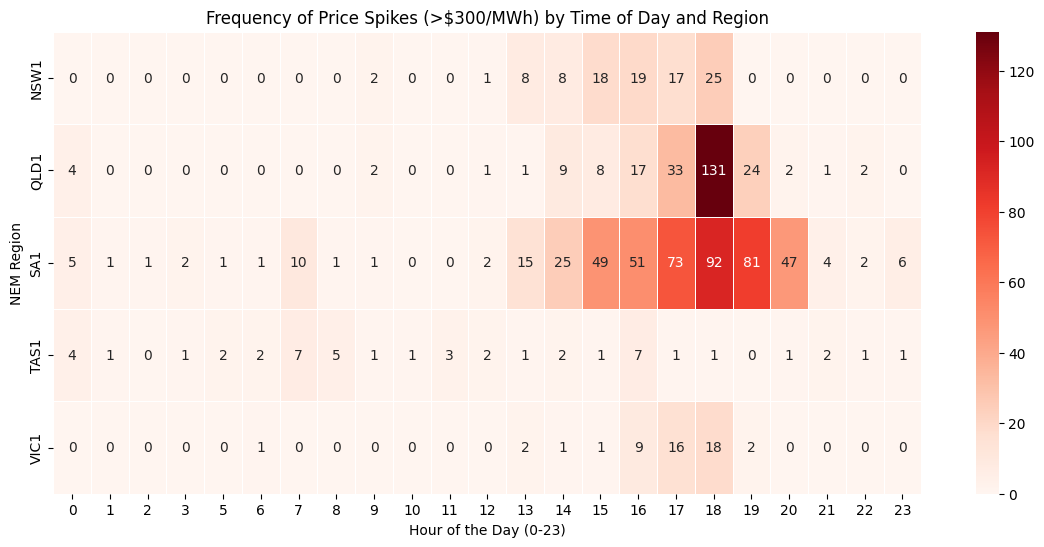

In [ ]:
#Q1: Which specific months and times of day experience the highest frequency of extreme wholesale price spikes (>$300/MWh)?

spike_threshold = 300

# Filter for spikes
spikes_df = nem_df[nem_df['RRP'] > spike_threshold]

# Group by Region and Hour
spike_counts = spikes_df.groupby(['REGIONID', 'Hour']).size().unstack(fill_value=0)

# Plotting a Heatmap of Spikes
plt.figure(figsize=(14, 6))
sns.heatmap(spike_counts, cmap='Reds', annot=True, fmt='d', linewidths=.5)
plt.title('Frequency of Price Spikes (>$300/MWh) by Time of Day and Region')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('NEM Region')
plt.show()

# Insight: Typically, you will see spikes concentrated around the 
# evening peak (17:00 - 19:00) when solar generation drops off but demand remains high.

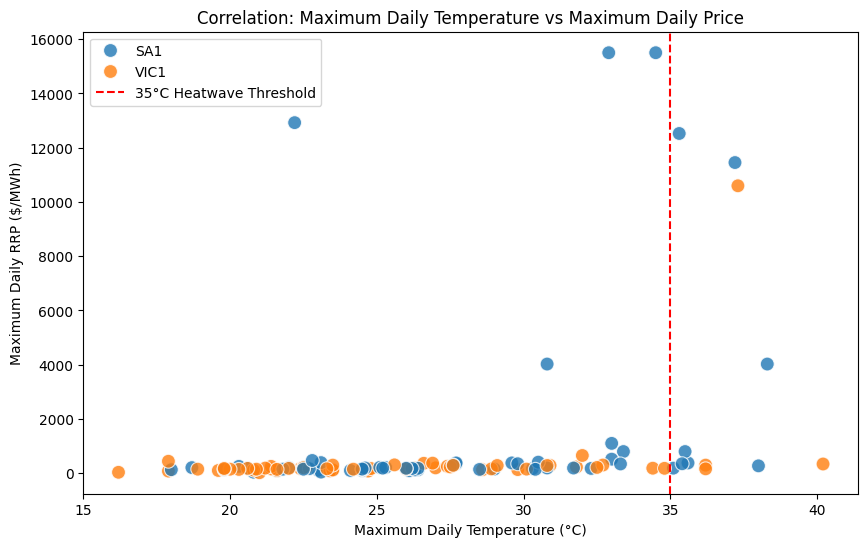

In [8]:
#Q2: How strongly do extreme temperature days (heatwaves >35°C) correlate with Regional Reference Price (RRP) blowouts in SA vs VIC?

# %%
# Filter for SA and VIC
sa_vic_df = nem_df[nem_df['REGIONID'].isin(['SA1', 'VIC1'])]

# To look at Daily Max RRP vs Daily Max Temp, we need to aggregate our 5-min data to daily
daily_summary = sa_vic_df.groupby(['Date', 'REGIONID']).agg(
    Daily_Max_RRP=('RRP', 'max'),
    MAX_TEMP=('MAX_TEMP', 'mean') # Temp is already daily, mean keeps it the same
).reset_index()

# Plotting
plt.figure(figsize=(10, 6))
sns.scatterplot(data=daily_summary, x='MAX_TEMP', y='Daily_Max_RRP', hue='REGIONID', s=100, alpha=0.8)
plt.axvline(x=35, color='red', linestyle='--', label='35°C Heatwave Threshold')
plt.title('Correlation: Maximum Daily Temperature vs Maximum Daily Price')
plt.xlabel('Maximum Daily Temperature (°C)')
plt.ylabel('Maximum Daily RRP ($/MWh)')
plt.legend()
plt.show()

C:\Users\Jerry\AppData\Local\Temp\ipykernel_13404\3614339285.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=neg_freq, x='REGIONID', y='Negative_Intervals_Count', palette='viridis')


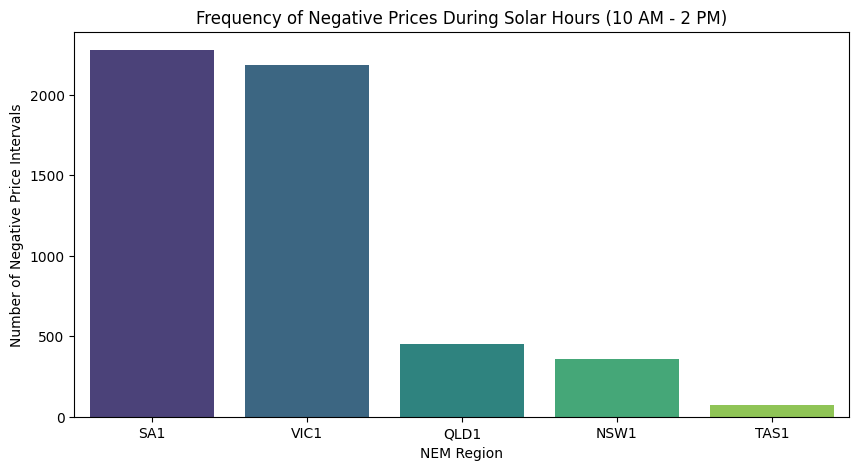

In [9]:
#Q3: What is the frequency of negative pricing intervals during peak solar hours (10:00 AM - 2:00 PM), and which state is most affected?

# %%
# Filter for peak solar hours (10 AM to 2 PM)
solar_hours = nem_df[(nem_df['Hour'] >= 10) & (nem_df['Hour'] <= 14)]

# Filter for negative prices
negative_prices = solar_hours[solar_hours['RRP'] < 0]

# Count frequencies by state
neg_freq = negative_prices['REGIONID'].value_counts().reset_index()
neg_freq.columns = ['REGIONID', 'Negative_Intervals_Count']

# Plotting
plt.figure(figsize=(10, 5))
sns.barplot(data=neg_freq, x='REGIONID', y='Negative_Intervals_Count', palette='viridis')
plt.title('Frequency of Negative Prices During Solar Hours (10 AM - 2 PM)')
plt.xlabel('NEM Region')
plt.ylabel('Number of Negative Price Intervals')
plt.show()

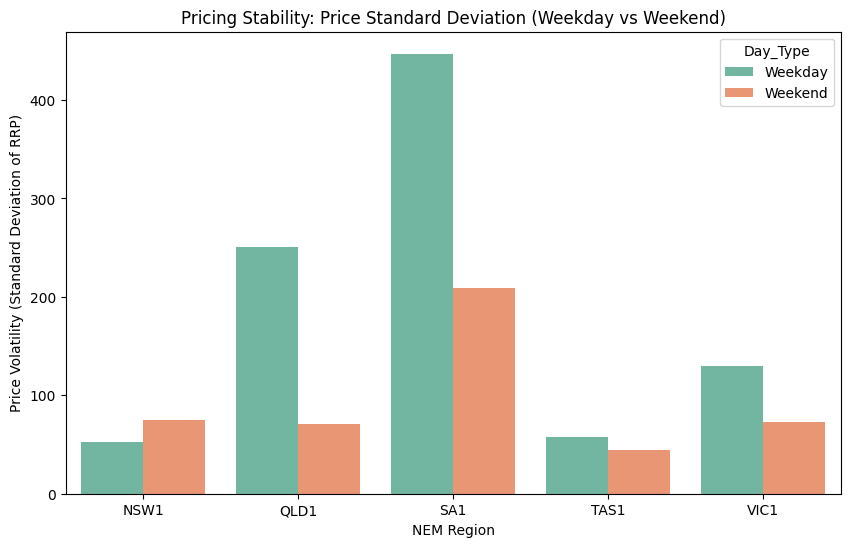

In [10]:
#Q4: How does the variance in operational demand between weekends and weekdays affect pricing stability?

# %%
# Calculate Price Volatility (Standard Deviation) by Weekday vs Weekend
volatility = nem_df.groupby(['REGIONID', 'Is_Weekend'])['RRP'].std().reset_index()
volatility.columns = ['REGIONID', 'Is_Weekend', 'Price_Std_Dev']
volatility['Day_Type'] = volatility['Is_Weekend'].map({True: 'Weekend', False: 'Weekday'})

plt.figure(figsize=(10, 6))
sns.barplot(data=volatility, x='REGIONID', y='Price_Std_Dev', hue='Day_Type', palette='Set2')
plt.title('Pricing Stability: Price Standard Deviation (Weekday vs Weekend)')
plt.ylabel('Price Volatility (Standard Deviation of RRP)')
plt.xlabel('NEM Region')
plt.show()

C:\Users\Jerry\AppData\Local\Temp\ipykernel_13404\560519988.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=peak_prices, x='REGIONID', y='RRP', palette='magma')


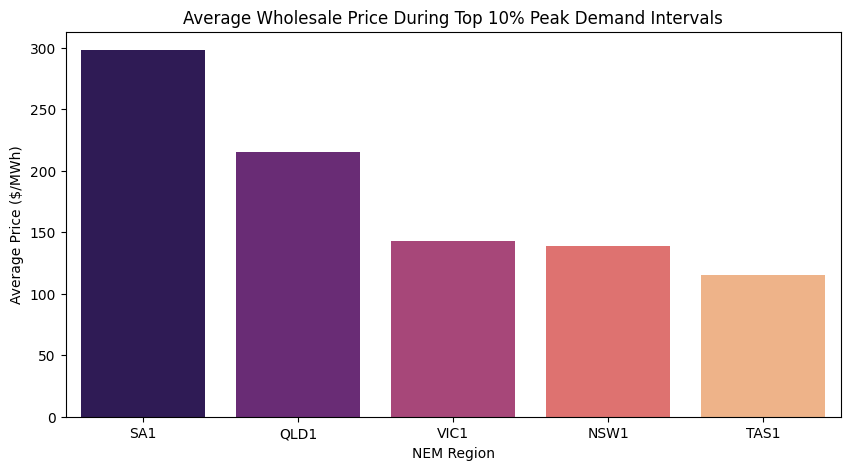

In [11]:
#Q5: During top 10% peak demand intervals, what is the average price differential between states?

# %%
# Calculate the 90th percentile demand threshold for EACH region
thresholds = nem_df.groupby('REGIONID')['TOTALDEMAND'].quantile(0.90).reset_index()
thresholds.rename(columns={'TOTALDEMAND': 'Demand_90th_Percentile'}, inplace=True)

# Merge thresholds back to main dataset
top_demand_df = pd.merge(nem_df, thresholds, on='REGIONID')

# Filter for intervals where demand exceeds the 90th percentile
top_10_percent = top_demand_df[top_demand_df['TOTALDEMAND'] >= top_demand_df['Demand_90th_Percentile']]

# Calculate average price during these peak times
peak_prices = top_10_percent.groupby('REGIONID')['RRP'].mean().reset_index().sort_values('RRP', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=peak_prices, x='REGIONID', y='RRP', palette='magma')
plt.title('Average Wholesale Price During Top 10% Peak Demand Intervals')
plt.ylabel('Average Price ($/MWh)')
plt.xlabel('NEM Region')
plt.show()

In [12]:
export_filename = 'NEM_Cleaned_Dashboard_Data.csv'
nem_df.to_csv(export_filename, index=False)